In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [78]:
# Load results
res_df = pd.read_csv("./graph2vec_classification_results.csv")

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [79]:
# Display basic information about the dataset
print("Dataset Overview:")
print(f"Shape: {res_df.shape}")
print(f"Columns: {list(res_df.columns)}")
print(f"Number of runs per configuration: {res_df.groupby(['Dataset', 'Classifier', 'Embedding_Dim']).size().unique()}")
print("\nFirst few rows:")
print(res_df.head())

Dataset Overview:
Shape: (90, 16)
Columns: ['Dataset', 'Classifier', 'Embedding_Dim', 'Run', 'Random_Seed', 'N_Samples', 'N_Classes', 'Accuracy', 'F1_Score', 'AUC', 'Train_Time_sec', 'Prediction_Time_sec', 'Generation_Time_sec', 'Memory_MB', 'Train_Samples', 'Test_Samples']
Number of runs per configuration: [5]

First few rows:
  Dataset Classifier  Embedding_Dim  Run  Random_Seed  N_Samples  N_Classes  \
0   MUTAG        SVM             32    1           42        188          2   
1   MUTAG        MLP             32    1           42        188          2   
2   MUTAG        SVM             32    2          123        188          2   
3   MUTAG        MLP             32    2          123        188          2   
4   MUTAG        SVM             32    3          456        188          2   

   Accuracy  F1_Score     AUC  Train_Time_sec  Prediction_Time_sec  \
0    0.7632    0.7341  0.6738           0.004                0.001   
1    0.7105    0.6892  0.7385           0.014          

In [80]:
metrics = ['Accuracy', 'F1_Score', 'AUC']
time_columns = ['Train_Time_sec', 'Prediction_Time_sec', 'Generation_Time_sec', 'Memory_MB']

# Calculate mean and std for each configuration for plotting
mean_df = res_df.groupby(['Dataset', 'Classifier', 'Embedding_Dim']).agg({
    'Accuracy': ['mean', 'std'],
    'F1_Score': ['mean', 'std'],
    'AUC': ['mean', 'std'],
    'Train_Time_sec': 'mean',
    'Prediction_Time_sec': 'mean',
    'Memory_MB': 'mean'
}).round(4)

# Flatten the multi-index columns
mean_df.columns = ['_'.join(col).strip() for col in mean_df.columns.values]
mean_df = mean_df.reset_index()

print("\nSummary statistics for plotting:")
print(mean_df.head())


Summary statistics for plotting:
   Dataset Classifier  Embedding_Dim  Accuracy_mean  Accuracy_std  \
0  ENZYMES        MLP             32         0.1850        0.0341   
1  ENZYMES        MLP             64         0.1700        0.0292   
2  ENZYMES        MLP            128         0.1817        0.0521   
3  ENZYMES        SVM             32         0.1917        0.0156   
4  ENZYMES        SVM             64         0.2083        0.0243   

   F1_Score_mean  F1_Score_std  AUC_mean  AUC_std  Train_Time_sec_mean  \
0         0.1593        0.0523    0.5184   0.0315               0.0178   
1         0.1650        0.0292    0.5437   0.0220               0.0318   
2         0.1714        0.0563    0.5190   0.0313               0.0970   
3         0.1734        0.0218    0.5343   0.0297               0.0454   
4         0.1903        0.0191    0.5539   0.0208               0.0664   

   Prediction_Time_sec_mean  Memory_MB_mean  
0                    0.0000           0.012  
1             

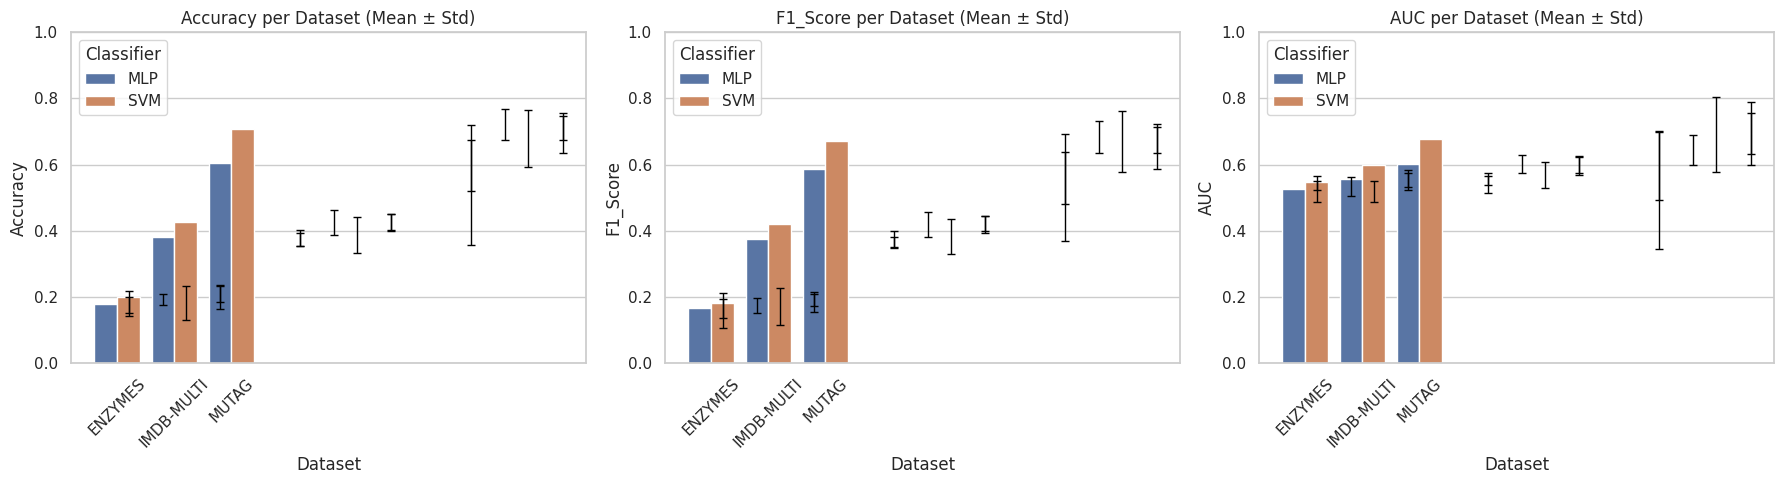

In [81]:
 # 1️⃣ Performance metrics comparison with error bars (now meaningful!)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    # Create bar plot with error bars
    sns.barplot(data=mean_df, x="Dataset", y=f"{metric}_mean", hue="Classifier", 
                ax=axes[i], errorbar=None)  # We'll add custom error bars
    
    # Add custom error bars manually
    for j, (idx, row) in enumerate(mean_df.iterrows()):
        x_pos = j
        # Adjust x position based on classifier
        classifier_offset = -0.2 if row['Classifier'] == 'SVM' else 0.2
        if len(mean_df['Classifier'].unique()) == 2:
            x_pos = j // 2 + classifier_offset
        
        axes[i].errorbar(x=x_pos, y=row[f'{metric}_mean'], 
                        yerr=row[f'{metric}_std'],
                        color='black', capsize=3, capthick=1, 
                        linewidth=1, fmt='none')
    
    axes[i].set_title(f"{metric} per Dataset (Mean ± Std)")
    axes[i].set_ylim(0, 1)
    axes[i].legend(title="Classifier")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel(f"{metric}")

plt.tight_layout()
plt.show()

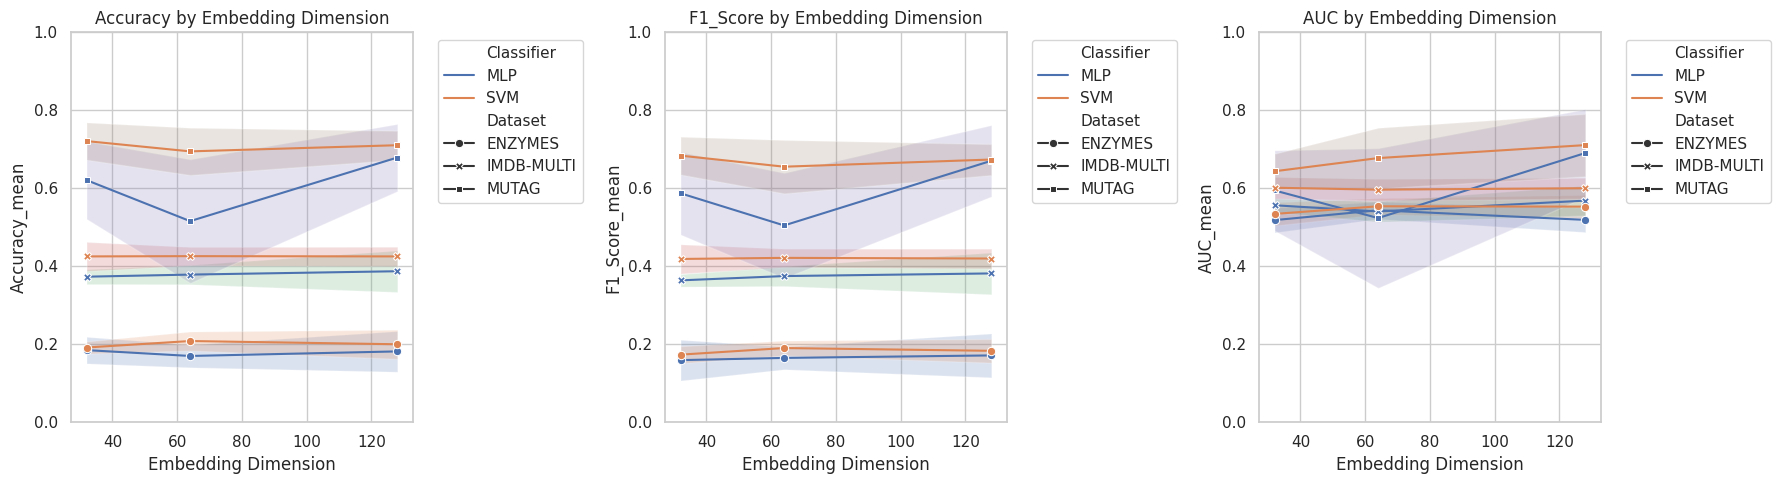

In [82]:
# 2️⃣ Performance metrics by embedding dimension with variability
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    # Use the original data to show all points
    sns.lineplot(data=mean_df, x="Embedding_Dim", y=f"{metric}_mean", 
                 hue="Classifier", style="Dataset", markers=True, 
                 dashes=False, ax=axes[i], legend='full')
    
    # Add error bars as shaded regions
    for dataset in mean_df['Dataset'].unique():
        for classifier in mean_df['Classifier'].unique():
            subset = mean_df[(mean_df['Dataset'] == dataset) & 
                            (mean_df['Classifier'] == classifier)]
            if not subset.empty:
                axes[i].fill_between(subset['Embedding_Dim'],
                                   subset[f'{metric}_mean'] - subset[f'{metric}_std'],
                                   subset[f'{metric}_mean'] + subset[f'{metric}_std'],
                                   alpha=0.2)
    
    axes[i].set_title(f"{metric} by Embedding Dimension")
    axes[i].set_ylim(0, 1)
    axes[i].set_xlabel("Embedding Dimension")
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


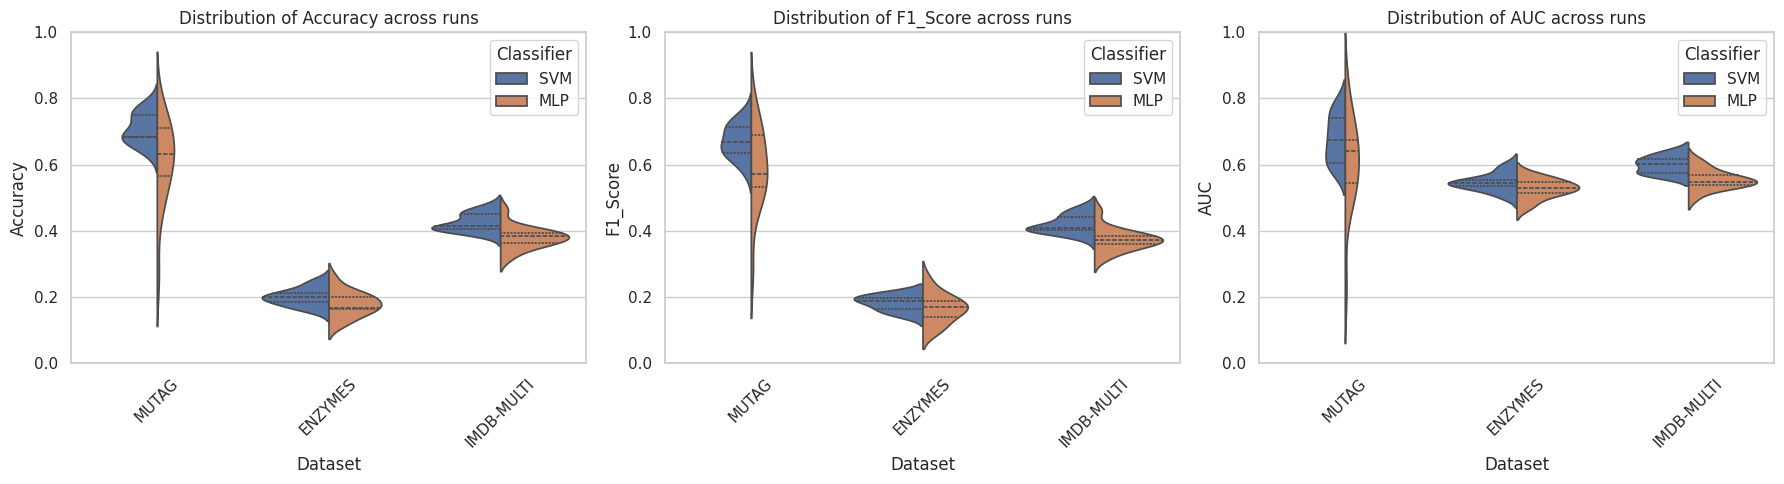

In [83]:
# 3️⃣ Distribution of results across runs (violin plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    sns.violinplot(data=res_df, x="Dataset", y=metric, hue="Classifier", 
                   ax=axes[i], split=True, inner="quartile")
    axes[i].set_title(f"Distribution of {metric} across runs")
    axes[i].set_ylim(0, 1)
    axes[i].legend(title="Classifier")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

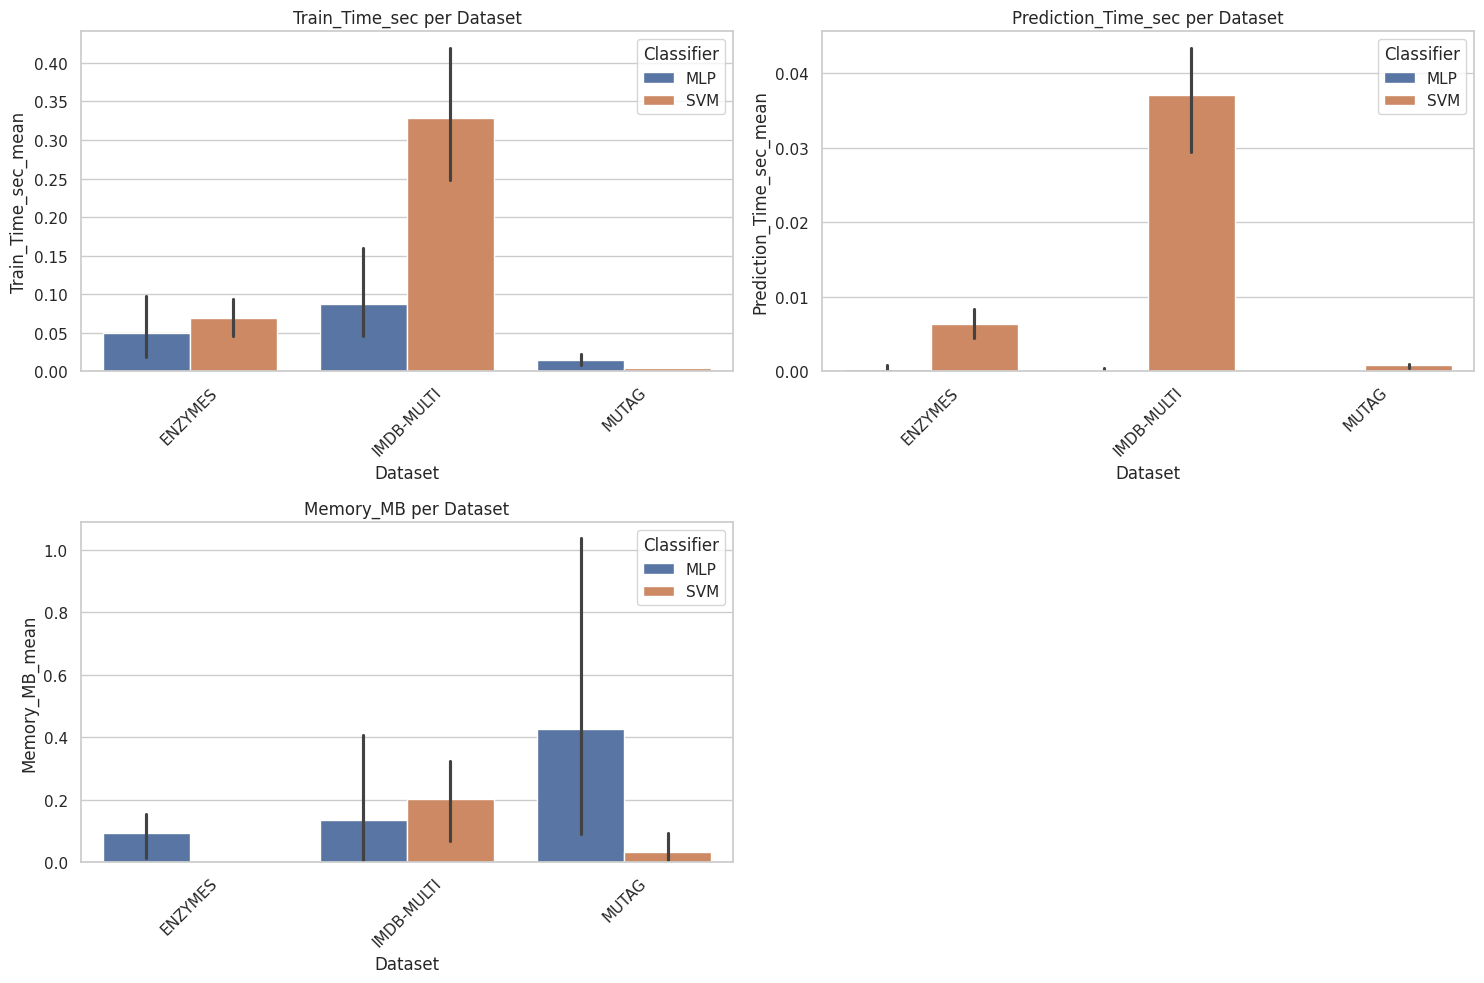

In [84]:
# 4️⃣ Time and memory analysis (fixed - using only existing columns)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Only plot the time columns that exist in mean_df
available_time_cols = [col for col in time_columns if f"{col}_mean" in mean_df.columns]

for i, metric in enumerate(available_time_cols[:4]):  # Only plot up to 4 subplots
    if i < len(axes):
        sns.barplot(data=mean_df, x="Dataset", y=f"{metric}_mean", hue="Classifier", ax=axes[i])
        axes[i].set_title(f"{metric} per Dataset")
        axes[i].legend(title="Classifier")
        axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for i in range(len(available_time_cols), 4):
    if i < len(axes):
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()


Performance Stability Analysis:
                                     Accuracy_mean  Accuracy_std  Accuracy_cv  \
Dataset    Classifier Embedding_Dim                                             
ENZYMES    MLP        32                    0.1850        0.0341       0.1841   
                      64                    0.1700        0.0292       0.1719   
                      128                   0.1817        0.0521       0.2870   
           SVM        32                    0.1917        0.0156       0.0812   
                      64                    0.2083        0.0243       0.1167   
                      128                   0.2000        0.0373       0.1864   
IMDB-MULTI MLP        32                    0.3733        0.0189       0.0506   
                      64                    0.3787        0.0248       0.0655   
                      128                   0.3873        0.0532       0.1374   
           SVM        32                    0.4253        0.0372       0.087

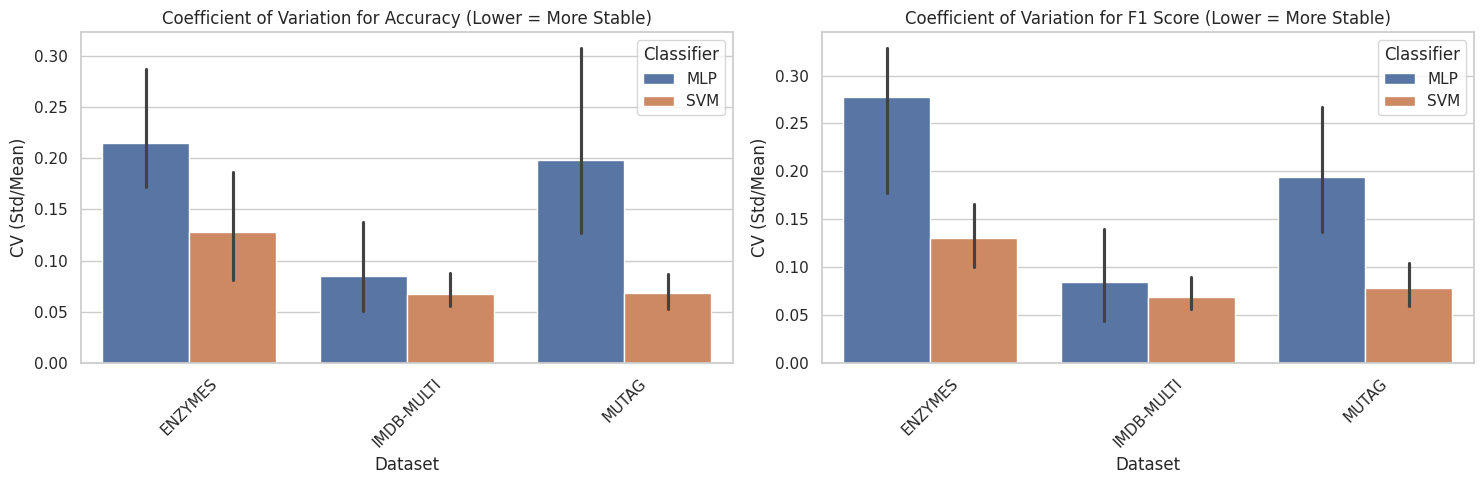

In [85]:
# 5️⃣ Performance stability analysis
print("\nPerformance Stability Analysis:")
stability = res_df.groupby(['Dataset', 'Classifier', 'Embedding_Dim']).agg({
    'Accuracy': ['mean', 'std', lambda x: x.std()/x.mean()],  # Coefficient of variation
    'F1_Score': ['mean', 'std', lambda x: x.std()/x.mean()]
}).round(4)

stability.columns = ['Accuracy_mean', 'Accuracy_std', 'Accuracy_cv', 
                     'F1_mean', 'F1_std', 'F1_cv']
print(stability)

# Visualize coefficient of variation (lower = more stable)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

stability_reset = stability.reset_index()

sns.barplot(data=stability_reset, x="Dataset", y="Accuracy_cv", hue="Classifier", ax=axes[0])
axes[0].set_title("Coefficient of Variation for Accuracy (Lower = More Stable)")
axes[0].set_ylabel("CV (Std/Mean)")
axes[0].legend(title="Classifier")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=stability_reset, x="Dataset", y="F1_cv", hue="Classifier", ax=axes[1])
axes[1].set_title("Coefficient of Variation for F1 Score (Lower = More Stable)")
axes[1].set_ylabel("CV (Std/Mean)")
axes[1].legend(title="Classifier")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [86]:
# 6️⃣ Best performing configurations (considering both mean and stability)
print("\nTop 5 Best Performing Configurations by Mean Accuracy:")
top_accuracy = mean_df.nlargest(5, 'Accuracy_mean')[['Dataset', 'Classifier', 'Embedding_Dim', 
                                                    'Accuracy_mean', 'Accuracy_std', 
                                                    'F1_Score_mean', 'AUC_mean']]
print(top_accuracy)

print("\nMost Stable Configurations (Lowest Coefficient of Variation):")
stable_configs = stability_reset.nsmallest(5, 'Accuracy_cv')[['Dataset', 'Classifier', 'Embedding_Dim', 
                                                            'Accuracy_mean', 'Accuracy_std', 'Accuracy_cv']]
print(stable_configs)



Top 5 Best Performing Configurations by Mean Accuracy:
   Dataset Classifier  Embedding_Dim  Accuracy_mean  Accuracy_std  \
15   MUTAG        SVM             32         0.7211        0.0478   
17   MUTAG        SVM            128         0.7105        0.0372   
16   MUTAG        SVM             64         0.6947        0.0606   
14   MUTAG        MLP            128         0.6789        0.0861   
12   MUTAG        MLP             32         0.6210        0.0995   

    F1_Score_mean  AUC_mean  
15         0.6838    0.6437  
17         0.6738    0.7108  
16         0.6554    0.6775  
14         0.6706    0.6905  
12         0.5872    0.5945  

Most Stable Configurations (Lowest Coefficient of Variation):
       Dataset Classifier  Embedding_Dim  Accuracy_mean  Accuracy_std  \
6   IMDB-MULTI        MLP             32         0.3733        0.0189   
17       MUTAG        SVM            128         0.7105        0.0372   
10  IMDB-MULTI        SVM             64         0.4260        0.02

In [87]:
# 7️⃣ Performance comparison between classifiers with statistical significance
from scipy import stats

print("\nStatistical Significance Testing (SVM vs MLP):")
for dataset in res_df['Dataset'].unique():
    dataset_data = res_df[res_df['Dataset'] == dataset]
    
    for emb_dim in dataset_data['Embedding_Dim'].unique():
        dim_data = dataset_data[dataset_data['Embedding_Dim'] == emb_dim]
        
        svm_scores = dim_data[dim_data['Classifier'] == 'SVM']['Accuracy']
        mlp_scores = dim_data[dim_data['Classifier'] == 'MLP']['Accuracy']
        
        if len(svm_scores) > 1 and len(mlp_scores) > 1:
            t_stat, p_value = stats.ttest_ind(svm_scores, mlp_scores)
            print(f"{dataset} (dim={emb_dim}): t={t_stat:.3f}, p={p_value:.3f} {'*' if p_value < 0.05 else ''}")


Statistical Significance Testing (SVM vs MLP):
MUTAG (dim=32): t=2.026, p=0.077 
MUTAG (dim=64): t=2.358, p=0.046 *
MUTAG (dim=128): t=0.753, p=0.473 
ENZYMES (dim=32): t=0.398, p=0.701 
ENZYMES (dim=64): t=2.254, p=0.054 
ENZYMES (dim=128): t=0.639, p=0.541 
IMDB-MULTI (dim=32): t=2.790, p=0.024 *
IMDB-MULTI (dim=64): t=3.092, p=0.015 *
IMDB-MULTI (dim=128): t=1.448, p=0.186 



Detailed Analysis for MUTAG


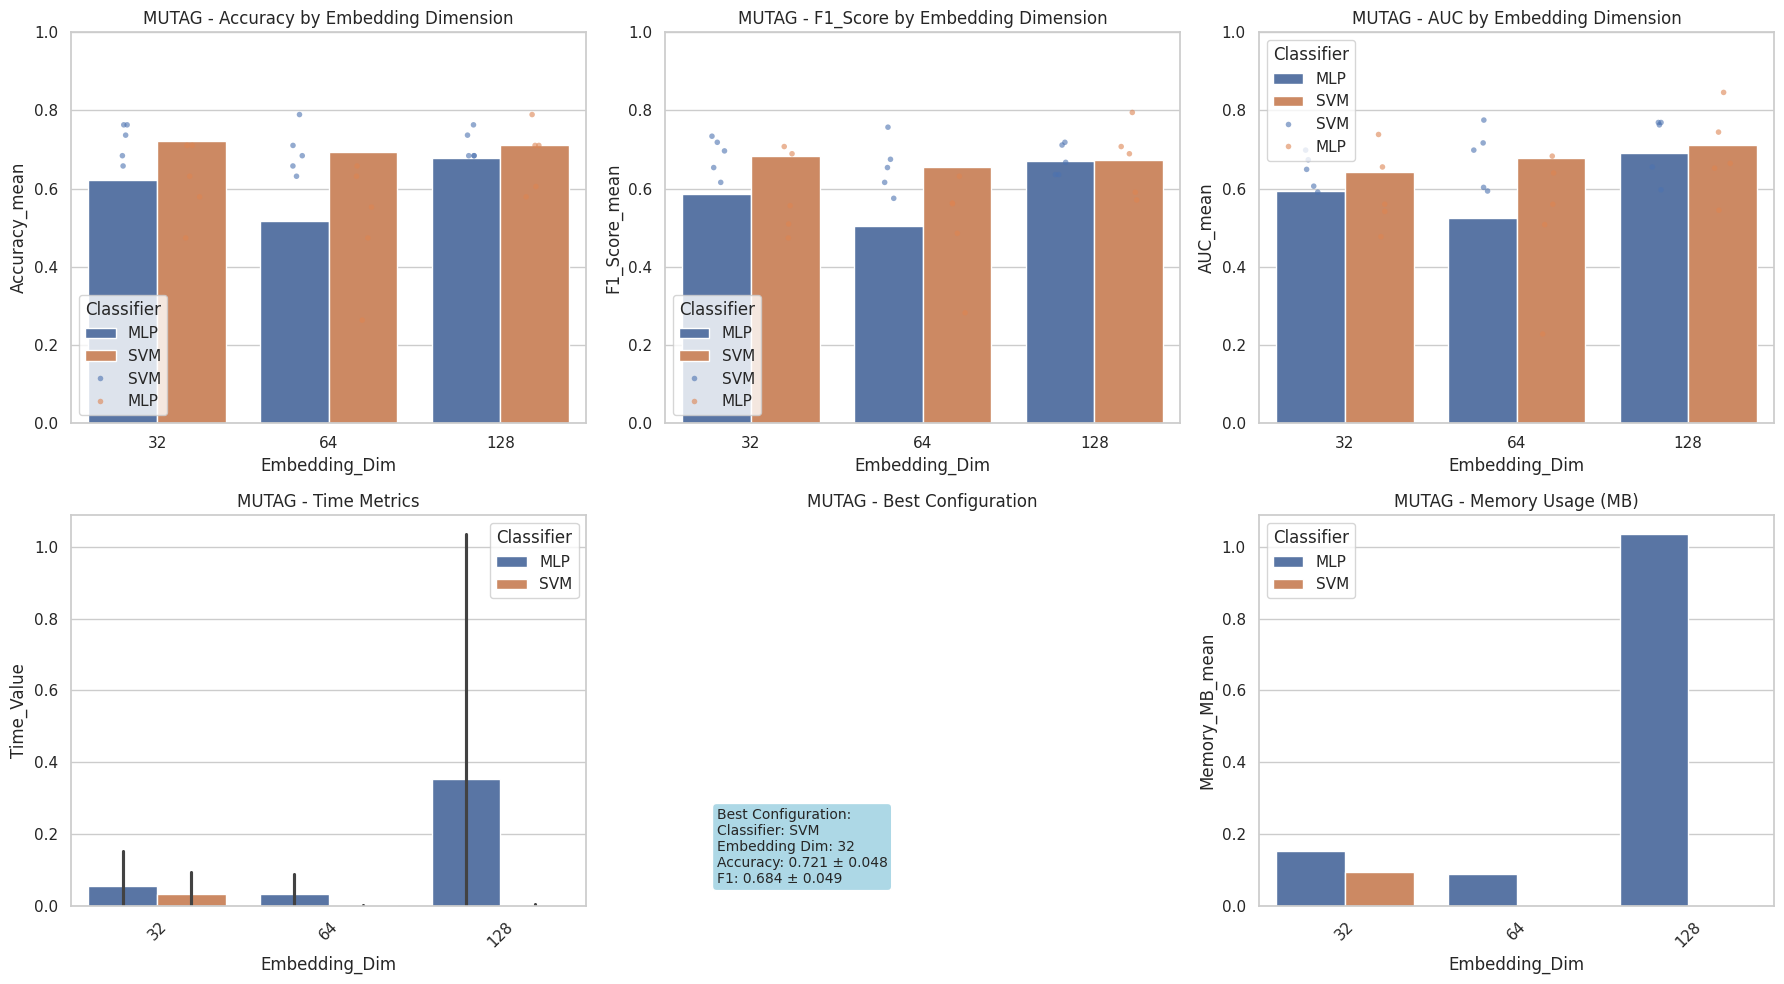


Detailed Analysis for ENZYMES


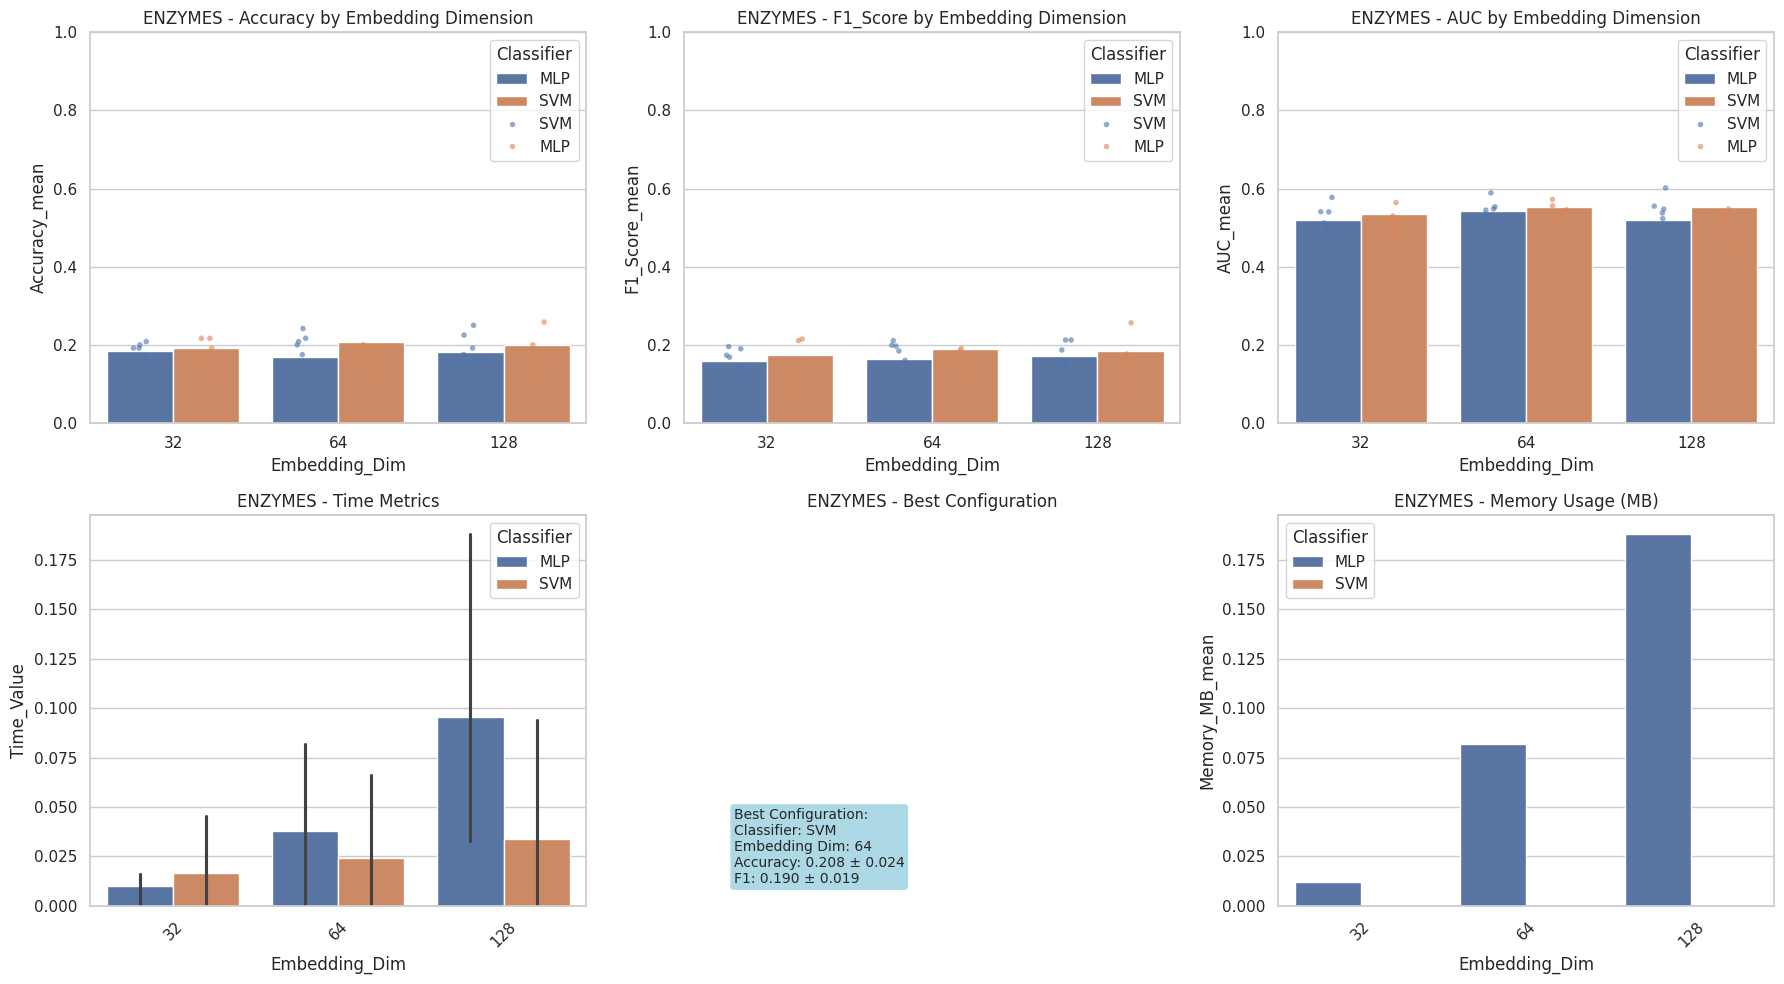


Detailed Analysis for IMDB-MULTI


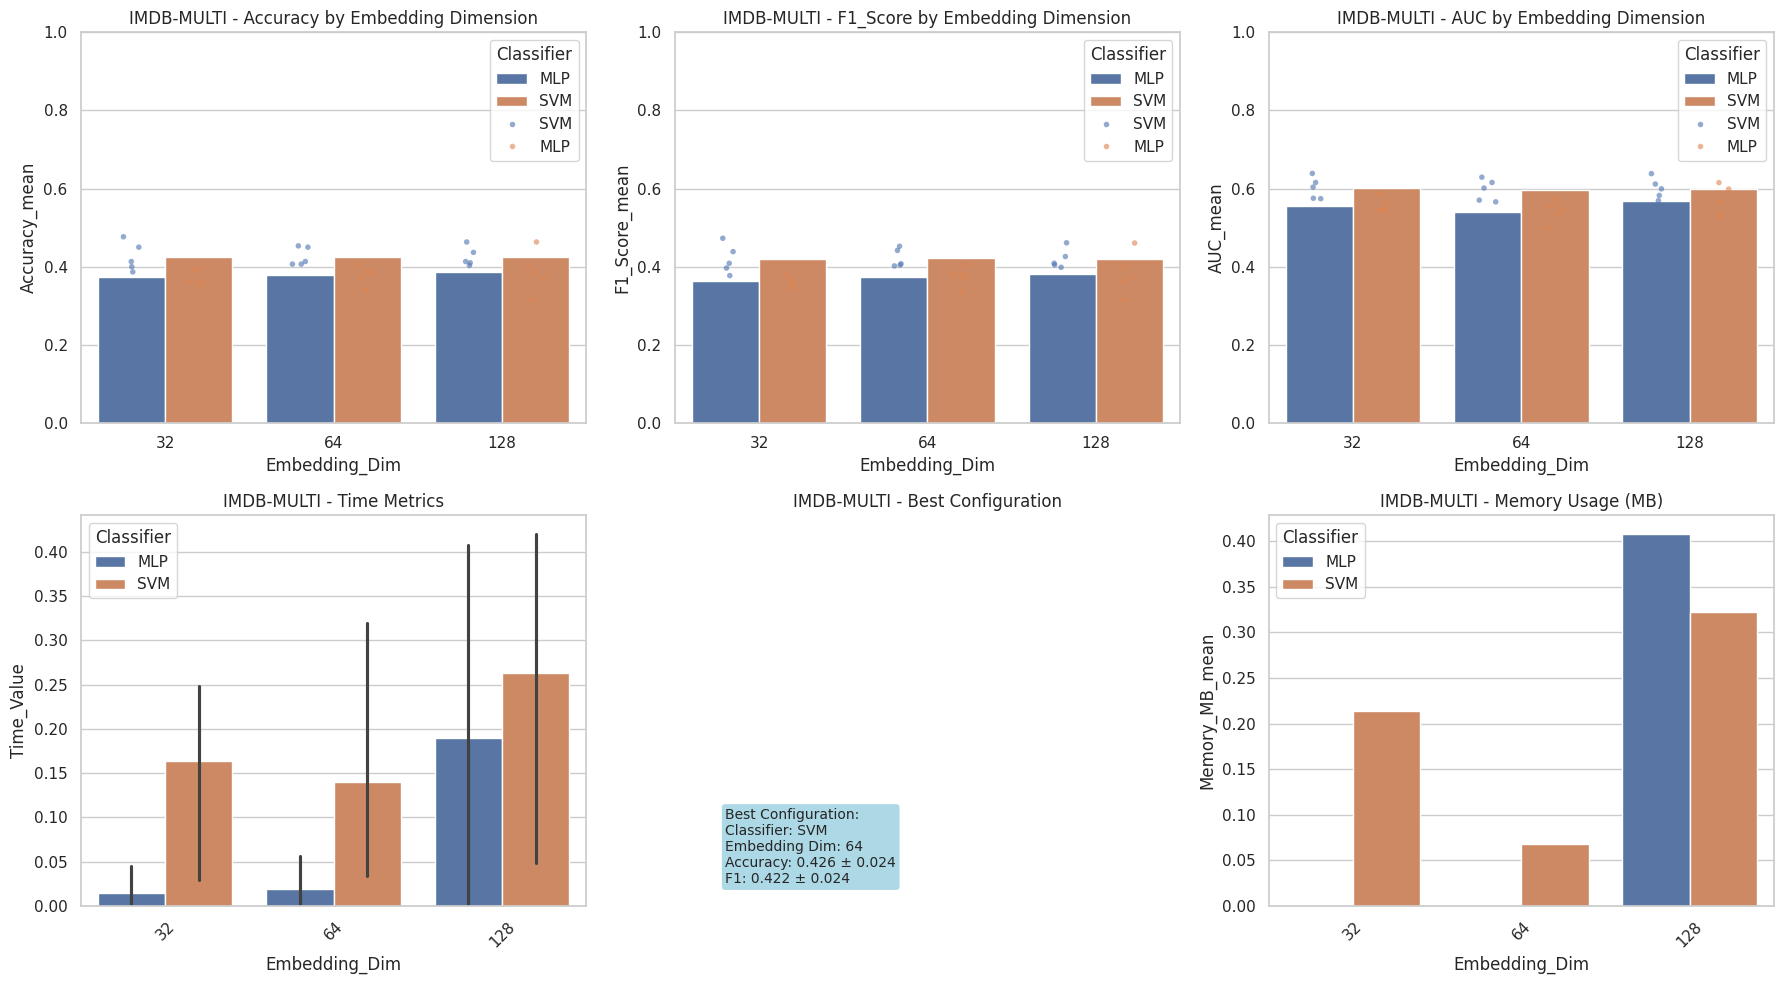

In [90]:
# 8️⃣ Detailed analysis per dataset with run distributions
datasets = res_df['Dataset'].unique()

for dataset in datasets:
    dataset_data = res_df[res_df['Dataset'] == dataset]
    dataset_mean = mean_df[mean_df['Dataset'] == dataset]
    
    print(f"\n{'='*50}")
    print(f"Detailed Analysis for {dataset}")
    print(f"{'='*50}")
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Performance metrics with individual runs
    for i, metric in enumerate(metrics):
        # Plot mean values
        sns.barplot(data=dataset_mean, x='Embedding_Dim', y=f'{metric}_mean', 
                    hue='Classifier', ax=axes[0, i])
        
        # Add individual data points
        sns.stripplot(data=dataset_data, x='Embedding_Dim', y=metric, 
                      hue='Classifier', ax=axes[0, i], dodge=True, 
                      alpha=0.6, size=4, jitter=True)
        
        axes[0, i].set_title(f'{dataset} - {metric} by Embedding Dimension')
        axes[0, i].set_ylim(0, 1)
    
    # Time metrics - ONLY USE COLUMNS THAT EXIST
    available_time_means = [f'{col}_mean' for col in time_columns if f'{col}_mean' in dataset_mean.columns]
    time_data = dataset_mean.melt(id_vars=['Classifier', 'Embedding_Dim'], 
                                 value_vars=available_time_means,
                                 var_name='Time_Metric', value_name='Time_Value')
    
    sns.barplot(data=time_data, x='Embedding_Dim', y='Time_Value', hue='Classifier', ax=axes[1, 0])
    axes[1, 0].set_title(f'{dataset} - Time Metrics')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Best configuration considering stability - TEXT AT BOTTOM
    best_config = dataset_mean.loc[dataset_mean['Accuracy_mean'].idxmax()]
    axes[1, 1].text(0.1, 0.05, f"Best Configuration:\n"
                              f"Classifier: {best_config['Classifier']}\n"
                              f"Embedding Dim: {best_config['Embedding_Dim']}\n"
                              f"Accuracy: {best_config['Accuracy_mean']:.3f} ± {best_config['Accuracy_std']:.3f}\n"
                              f"F1: {best_config['F1_Score_mean']:.3f} ± {best_config['F1_Score_std']:.3f}", 
                   transform=axes[1, 1].transAxes, fontsize=10,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"),
                   verticalalignment='bottom')
    axes[1, 1].set_title(f'{dataset} - Best Configuration')
    axes[1, 1].axis('off')
    
    # Memory usage
    sns.barplot(data=dataset_mean, x='Embedding_Dim', y='Memory_MB_mean', hue='Classifier', ax=axes[1, 2])
    axes[1, 2].set_title(f'{dataset} - Memory Usage (MB)')
    axes[1, 2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


In [ ]:
# 9️⃣ Summary statistics
print("\\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print(f"\\nTotal number of experiments: {len(res_df)}")
print(f"Datasets: {list(datasets)}")
print(f"Classifiers: {list(res_df['Classifier'].unique())}")
print(f"Embedding Dimensions: {list(res_df['Embedding_Dim'].unique())}")

# Overall best configuration
overall_best = res_df.loc[res_df['Accuracy'].idxmax()]
print(f"\\nOverall Best Configuration:")
print(f"  Dataset: {overall_best['Dataset']}")
print(f"  Classifier: {overall_best['Classifier']}")
print(f"  Embedding Dimension: {overall_best['Embedding_Dim']}")
print(f"  Accuracy: {overall_best['Accuracy']:.4f}")
print(f"  F1 Score: {overall_best['F1_Score']:.4f}")
print(f"  AUC: {overall_best['AUC']:.4f}")

# Performance ranges
print(f"\\nPerformance Ranges:")
for metric in metrics:
    min_val = res_df[metric].min()
    max_val = res_df[metric].max()
    mean_val = res_df[metric].mean()
    print(f"  {metric}: Min={min_val:.4f}, Max={max_val:.4f}, Mean={mean_val:.4f}")

\n============================================================
SUMMARY STATISTICS
\nTotal number of experiments: 90
Datasets: ['MUTAG', 'ENZYMES', 'IMDB-MULTI']
Classifiers: ['SVM', 'MLP']
Embedding Dimensions: [np.int64(32), np.int64(64), np.int64(128)]
\nOverall Best Configuration:
  Dataset: MUTAG
  Classifier: SVM
  Embedding Dimension: 64
  Accuracy: 0.7895
  F1 Score: 0.7572
  AUC: 0.7754
\nPerformance Ranges:
  Accuracy: Min=0.1167, Max=0.7895, Mean=0.4164
  F1_Score: Min=0.0946, Max=0.7949, Mean=0.3999
  AUC: Min=0.2277, Max=0.8462, Mean=0.5848
